Rendimientos esperados originales: [0.08 0.1  0.06 0.09]
Rendimiento de mercado: 0.086
Nuevos rendimientos esperados posteriores: [0.05624842 0.08702625 0.03914071 0.0759307 ]
Pesos óptimos: [0.1        0.69998602 0.09999977 0.10001421]


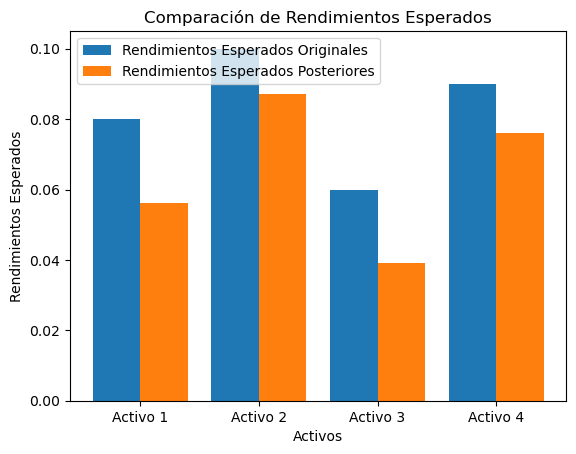

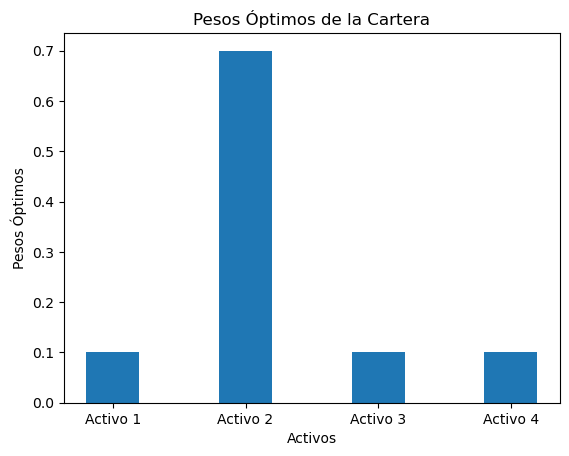

In [12]:
# Modelos de Black - Litterman

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Datos iniciales
cov_matrix = np.array([[0.04, 0.02, 0.01, 0.03],
                       [0.02, 0.09, 0.05, 0.01],
                       [0.01, 0.05, 0.06, 0.02],
                       [0.03, 0.01, 0.02, 0.07]])  # Matriz de covarianza de los activos
market_weights = np.array([0.25, 0.3, 0.15, 0.3])  # Pesos de mercado de los activos
risk_aversion = 0.05  # Aversión al riesgo del inversionista

# Estimación inicial de los rendimientos esperados
expected_returns = np.array([0.08, 0.10, 0.06, 0.09])

# Matriz de confianza de las perspectivas
confidence_matrix = np.array([[0.8, 0.0, 0.0, 0.0],
                              [0.0, 0.7, 0.0, 0.0],
                              [0.0, 0.0, 0.6, 0.0],
                              [0.0, 0.0, 0.0, 0.5]])

# Vector de perspectivas de rendimientos
views = np.array([0.02, 0.04, -0.01, 0.03])

# Cálculo del rendimiento de mercado
market_return = np.dot(market_weights, expected_returns)

# Cálculo del factor de ajuste utilizando el teorema de Bayes
posterior_covariance = np.linalg.inv(np.linalg.inv(cov_matrix) + np.dot(np.dot(np.transpose(confidence_matrix), np.linalg.inv(cov_matrix)), confidence_matrix))
posterior_mean = np.dot(posterior_covariance, (np.dot(np.linalg.inv(cov_matrix), expected_returns) + np.dot(np.dot(np.transpose(confidence_matrix), np.linalg.inv(cov_matrix)), views)))

# Función objetivo para la optimización
def objective(weights):
    return -np.dot(weights, posterior_mean)

# Restricciones
def constraint1(weights):
    return np.sum(weights) - 1.0

def constraint2(weights):
    return min(weights) - 0.10

# Optimización de la cartera
bounds = [(0, None)] * len(expected_returns)  # Límites de los pesos (0, infinito)
constraints = [{'type': 'eq', 'fun': constraint1}, {'type': 'ineq', 'fun': constraint2}]
initial_guess = np.ones(len(expected_returns)) / len(expected_returns)  # Peso inicial igualmente distribuido
result = minimize(objective, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)
opt_weights = result.x

# Resultados
print("Rendimientos esperados originales:", expected_returns)
print("Rendimiento de mercado:", market_return)
print("Nuevos rendimientos esperados posteriores:", posterior_mean)
print("Pesos óptimos:", opt_weights)

# Gráfico de los rendimientos esperados originales y nuevos
x = np.arange(len(expected_returns))
plt.bar(x, expected_returns, width=0.4, align='center', label='Rendimientos Esperados Originales')
plt.bar(x+0.4, posterior_mean, width=0.4, align='center', label='Rendimientos Esperados Posteriores')
plt.xticks(x+0.2, ['Activo 1', 'Activo 2', 'Activo 3', 'Activo 4'])
plt.xlabel('Activos')
plt.ylabel('Rendimientos Esperados')
plt.title('Comparación de Rendimientos Esperados')
plt.legend()
plt.show()

# Gráfico de los pesos óptimos
plt.bar(x, opt_weights, width=0.4, align='center')
plt.xticks(x, ['Activo 1', 'Activo 2', 'Activo 3', 'Activo 4'])
plt.xlabel('Activos')
plt.ylabel('Pesos Óptimos')
plt.title('Pesos Óptimos de la Cartera')
plt.show()